بسم الله

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from tabulate import tabulate

# إعدادات العرض
sns.set(style='whitegrid', palette='muted', color_codes=True)

# النمذجة التنبؤية
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# تثبيت العشوائية
import random
random.seed(42)
np.random.seed(42)

# مكتبة الإحصاء والتحذيرات
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/khushikyad001/global-war-and-conflict-impact-dataset-19502024/global_conflicts_dataset.csv")
df.head()

,Country_A,Country_B,Conflict_Type,Year,Duration_Days,Military_Deaths_A,Military_Deaths_B,Civilian_Deaths,Economic_Loss_USD_Billions,Temperature_Avg_C,...,Naval_Battles,Sanctions,Refugees_Millions,Ceasefire,Outcome,Latitude,Longitude,Climate_Zone,Resource_Dispute,UN_Involvement
0,France,France,Cold Conflict,2020,1829,33197,41305,50364,176.45,8.2,...,104,Yes,6.68,No,Victory_A,88.811,101.020,Temperate,Land,Yes
1,India,Japan,Cold Conflict,2013,1234,26773,10526,176846,435.83,24.8,...,87,Yes,14.51,Yes,Stalemate,55.878,78.502,Polar,Water,No
2,Israel,USA,Civil War,1970,1982,17256,7604,17280,154.50,17.3,...,9,No,1.63,No,Stalemate,29.263,144.680,Tropical,Water,No
3,Turkey,Australia,Proxy War,2021,1754,1745,33468,92279,273.20,12.3,...,15,No,7.23,No,Victory_A,-22.281,-147.397,Polar,Water,No
4,Australia,France,War,2012,753,29149,40672,72545,351.35,31.1,...,22,Yes,19.65,No,Victory_A,17.638,169.360,Temperate,Land,No


In [3]:
df.tail()


,Country_A,Country_B,Conflict_Type,Year,Duration_Days,Military_Deaths_A,Military_Deaths_B,Civilian_Deaths,Economic_Loss_USD_Billions,Temperature_Avg_C,...,Naval_Battles,Sanctions,Refugees_Millions,Ceasefire,Outcome,Latitude,Longitude,Climate_Zone,Resource_Dispute,UN_Involvement
2995,China,France,Skirmish,1980,395,4452,45602,23016,465.44,4.1,...,162,Yes,10.62,No,Victory_A,71.175,36.407,Polar,Oil,Yes
2996,Russia,Russia,Cold Conflict,2009,300,284,627,175145,265.39,7.9,...,2,No,5.12,Yes,Victory_B,-42.396,-0.958,Polar,Oil,No
2997,Canada,Israel,War,2019,1550,10484,3022,11370,461.47,21.5,...,32,No,2.47,No,Victory_A,-29.783,19.301,Arid,Land,Yes
2998,Germany,Turkey,Cold Conflict,1966,749,14419,5949,188963,103.94,31.2,...,6,No,7.26,No,Victory_A,81.474,42.923,Arid,NaN,No
2999,Israel,India,War,1999,285,20549,30400,65175,302.32,-6.1,...,104,Yes,8.58,Yes,Victory_A,-78.367,65.547,Arid,Oil,No


In [4]:
df.shape


(3000, 30)

In [5]:
df.describe()


,Year,Duration_Days,Military_Deaths_A,Military_Deaths_B,Civilian_Deaths,Economic_Loss_USD_Billions,Temperature_Avg_C,Rainfall_mm,Population_A_Millions,Population_B_Millions,GDP_A_Billions,GDP_B_Billions,Air_Strikes,Naval_Battles,Refugees_Millions,Latitude,Longitude
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1987.338000,1003.734667,24423.385000,24959.623333,100151.649333,253.684450,12.928667,1538.184333,709.784867,697.569867,12329.562933,12439.594433,2489.252000,98.849667,10.082663,-0.146093,0.469165
std,21.766006,568.221869,14129.940099,14345.873994,57927.462774,142.903418,13.094564,862.818221,400.912716,403.902829,7226.239780,7168.683362,1448.823011,58.377493,5.784529,51.958831,103.241034
min,1950.000000,2.000000,105.000000,119.000000,68.000000,0.230000,-10.000000,0.100000,2.600000,1.100000,14.100000,30.900000,0.000000,0.000000,0.000000,-89.992000,-179.903000
25%,1968.000000,529.000000,12292.000000,12768.250000,49719.500000,132.905000,1.700000,796.725000,370.950000,354.100000,6035.450000,6394.050000,1228.750000,47.000000,5.127500,-44.309250,-86.960500
50%,1987.000000,999.000000,23889.000000,24270.000000,100106.500000,257.580000,13.000000,1547.650000,711.300000,699.850000,12388.400000,12357.800000,2457.000000,99.000000,10.155000,-0.413500,-1.689500
75%,2007.000000,1493.000000,36801.000000,37424.500000,149615.750000,374.897500,24.200000,2282.350000,1053.525000,1050.025000,18581.175000,18521.675000,3738.250000,151.000000,15.110000,44.981500,89.974750
max,2024.000000,1999.000000,49995.000000,49992.000000,199972.000000,499.960000,35.000000,2999.000000,1400.000000,1399.700000,24995.200000,24997.500000,4999.000000,199.000000,20.000000,89.989000,179.888000


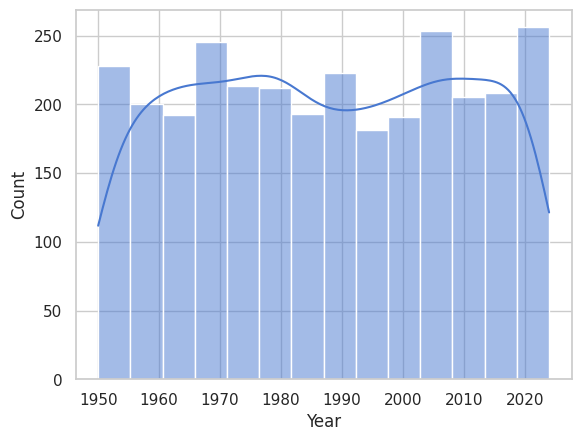

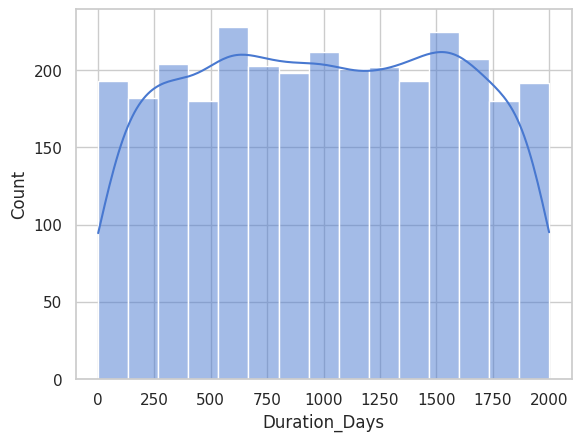

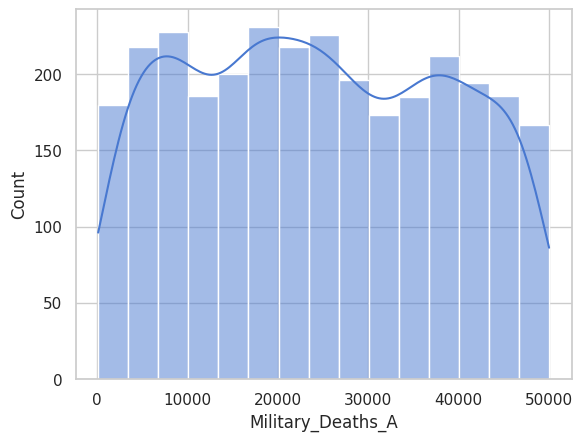

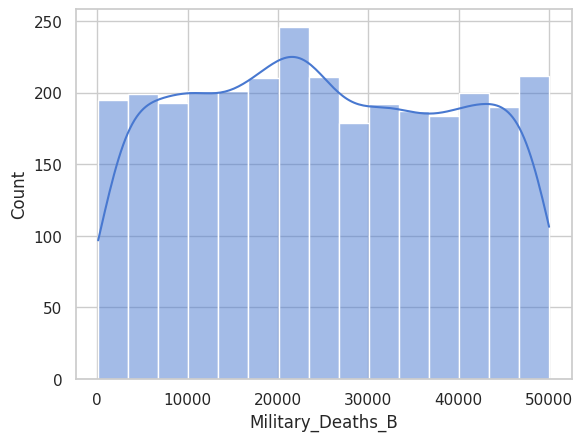

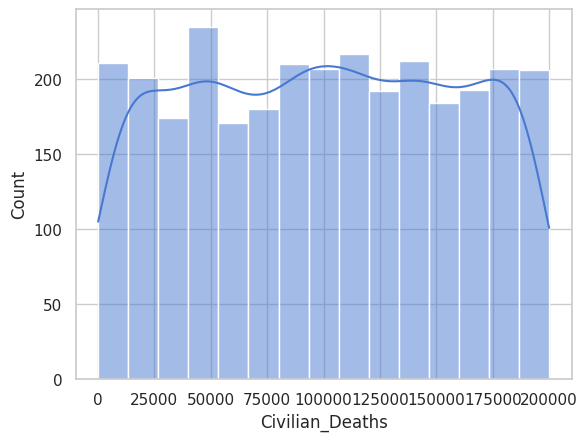

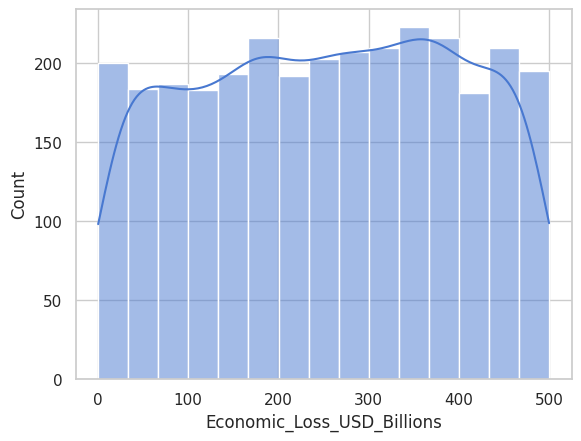

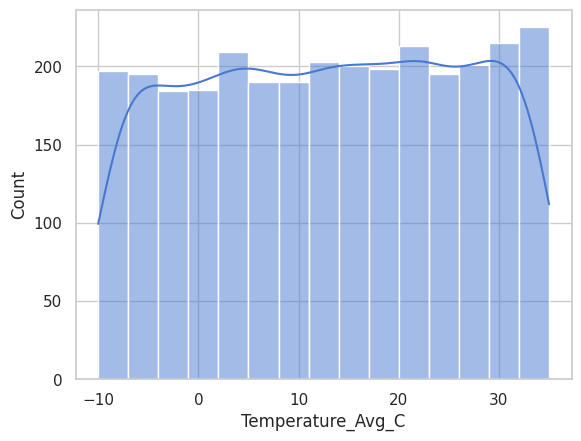

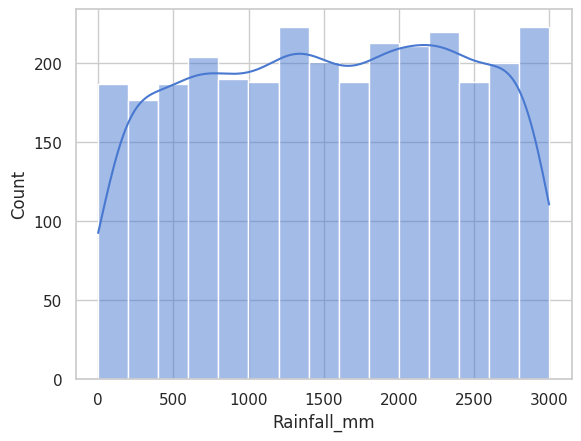

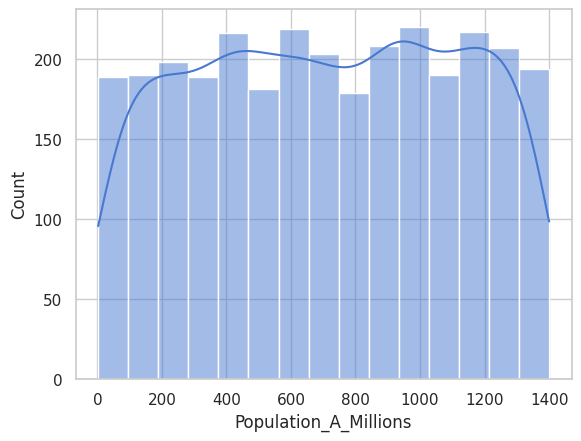

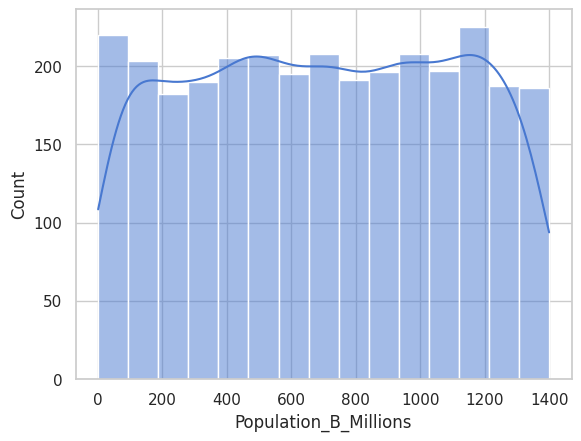

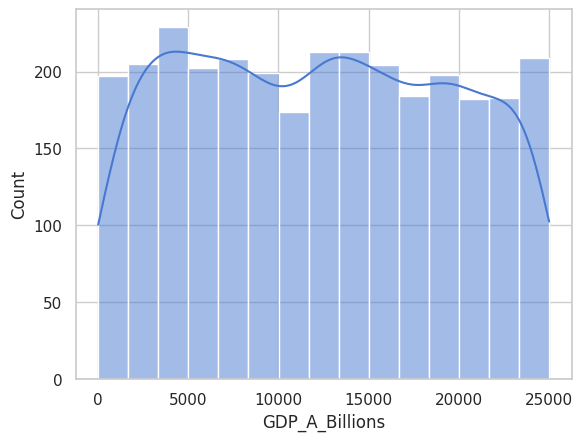

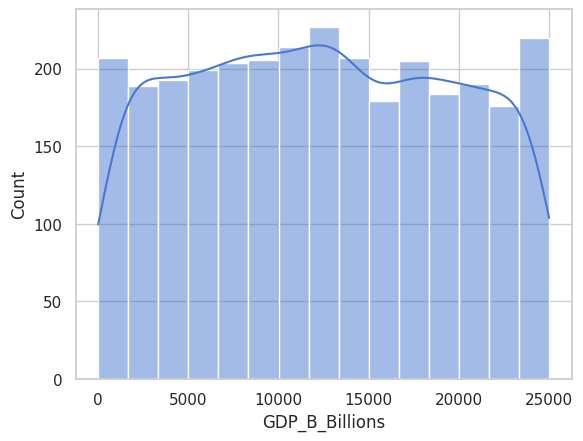

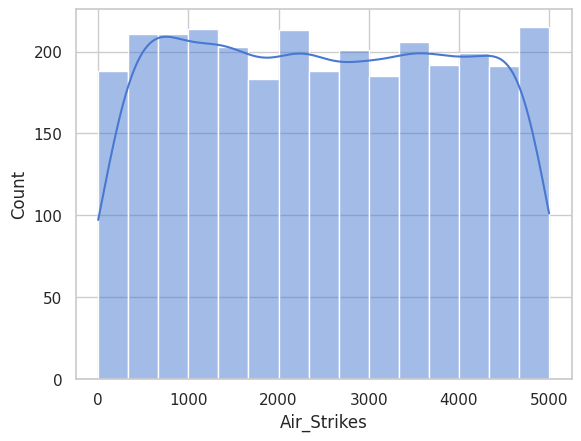

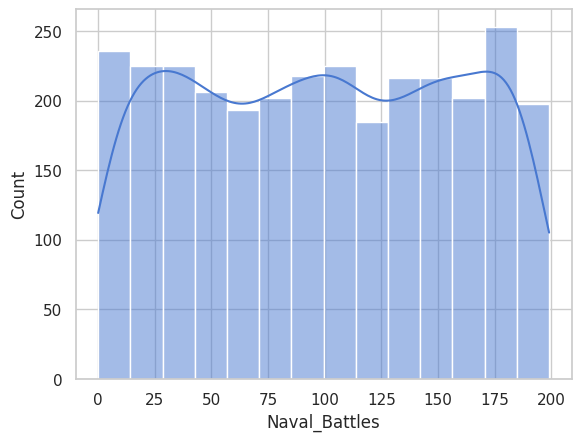

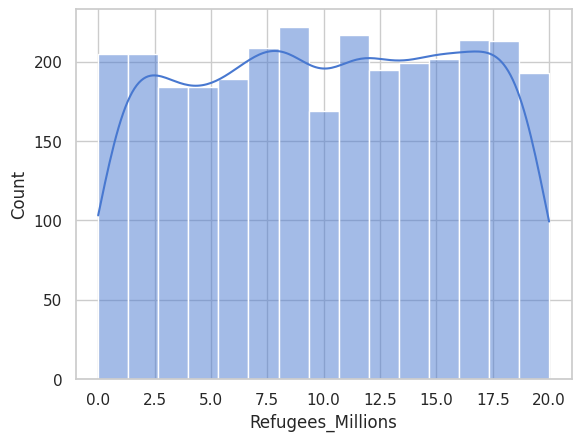

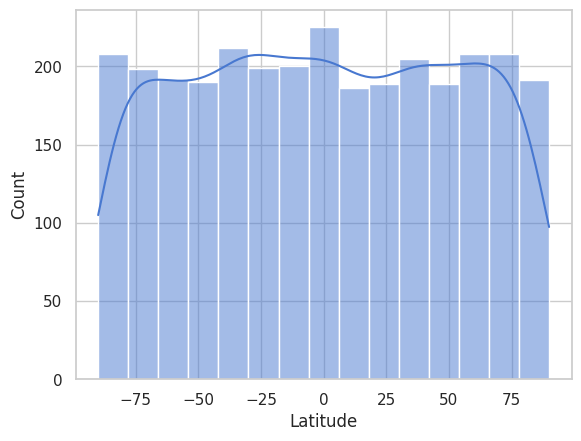

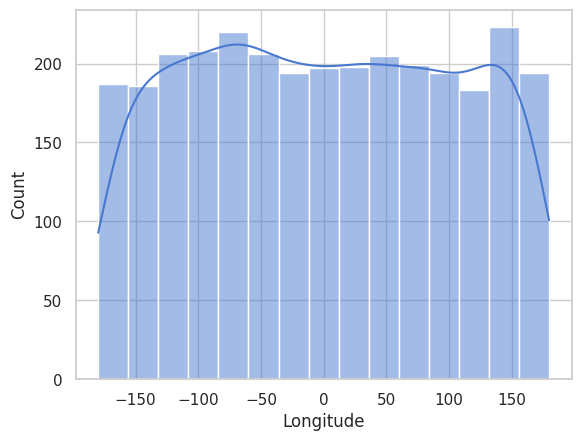

In [6]:
numeric_cols = df.select_dtypes(include=['number']).columns

# رسم التوزيع لكل عمود رقمي
for col in numeric_cols:
    sns.histplot(x=col, data=df, kde=True)
    plt.show()

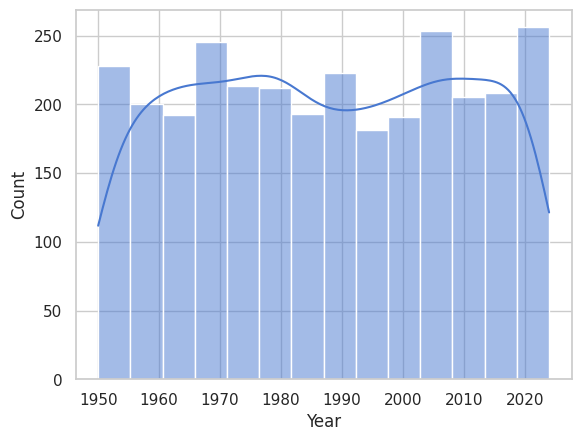

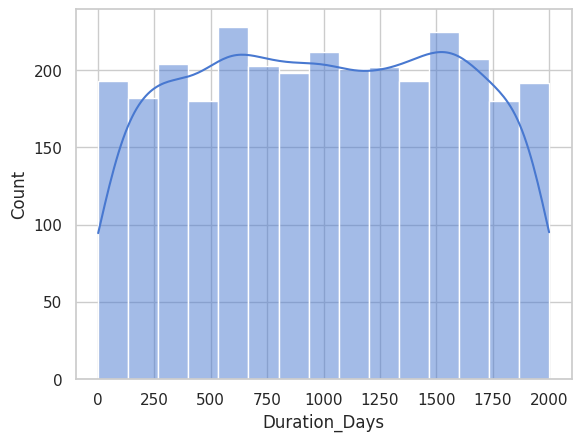

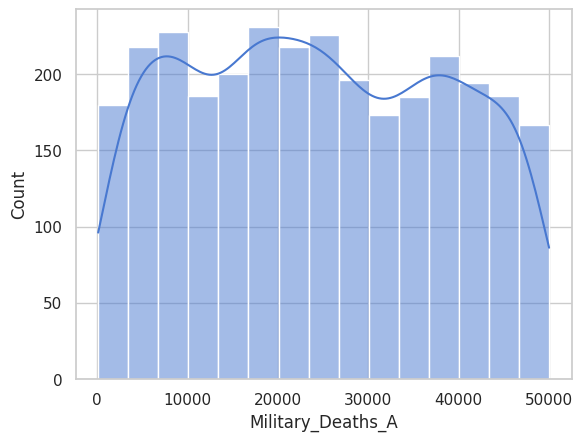

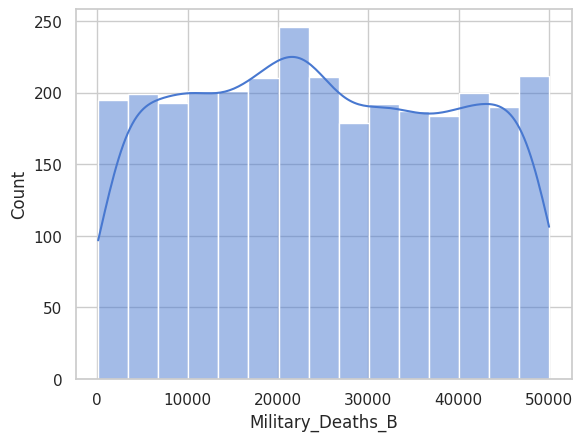

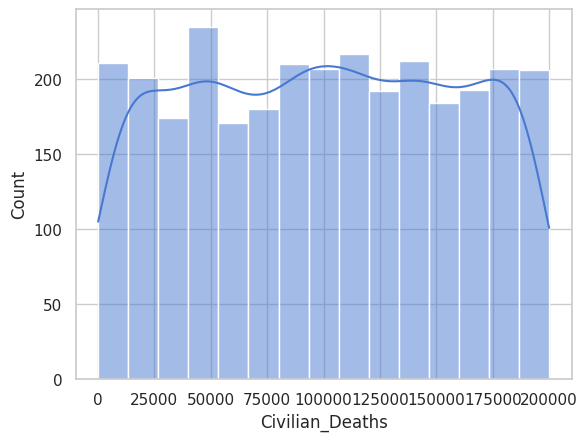

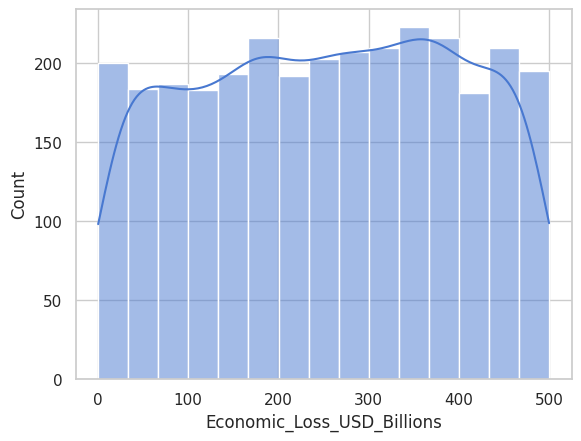

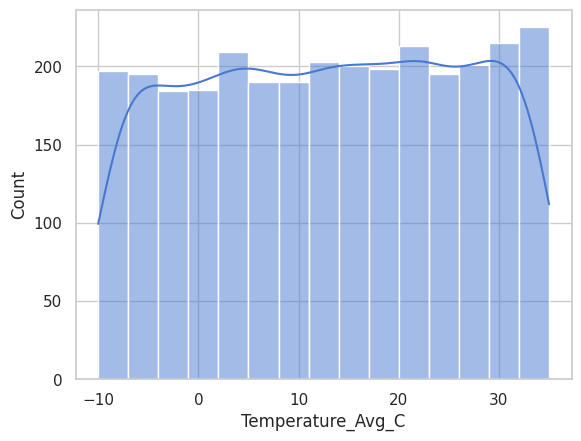

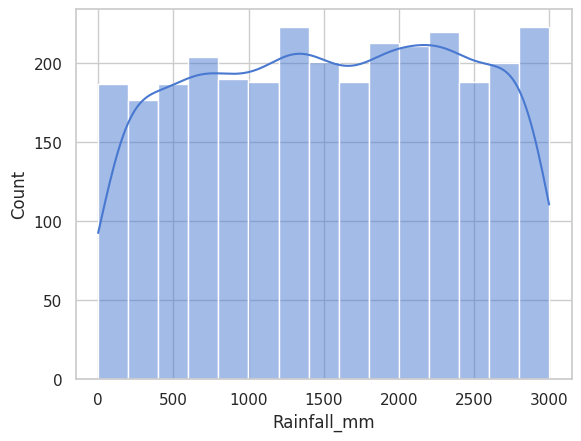

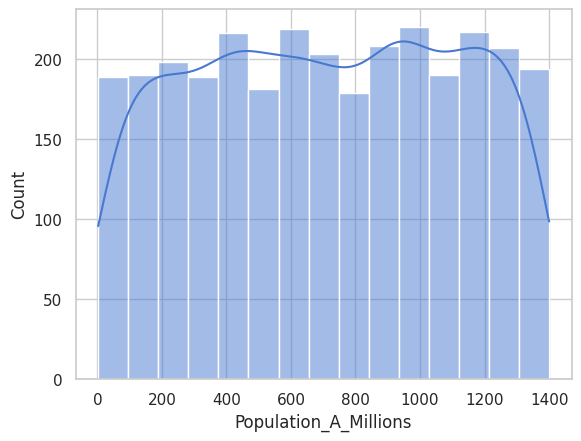

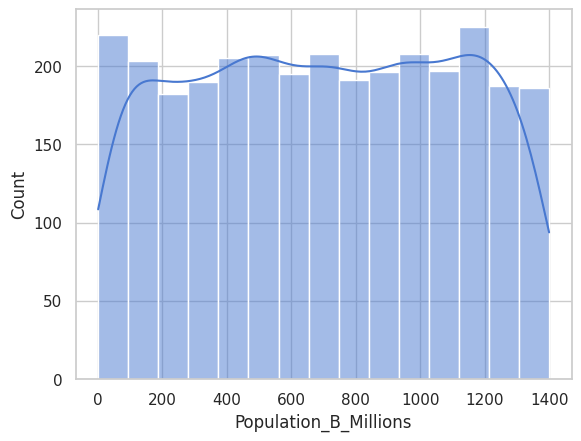

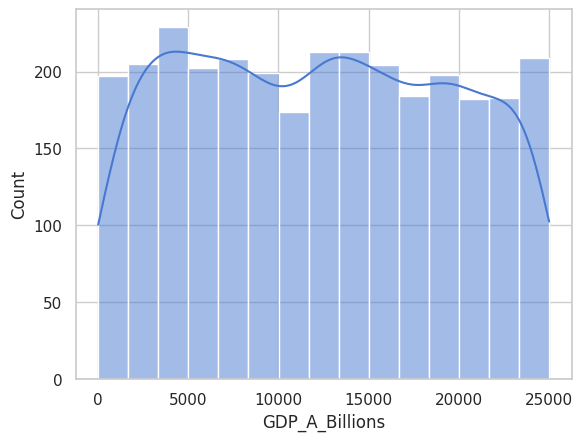

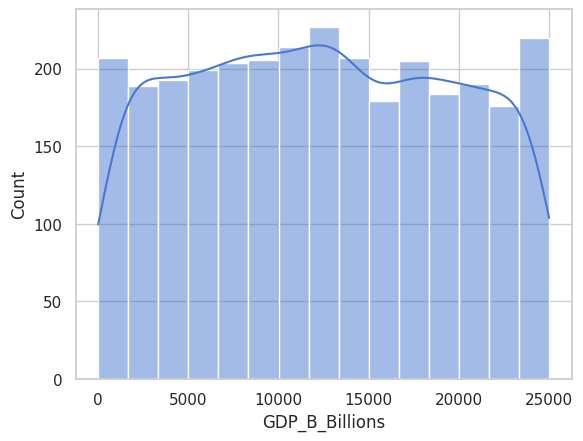

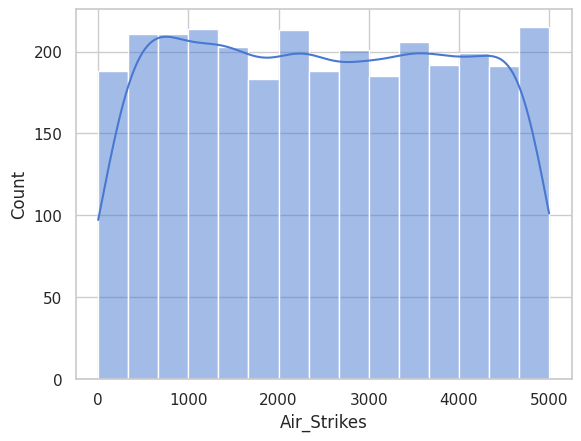

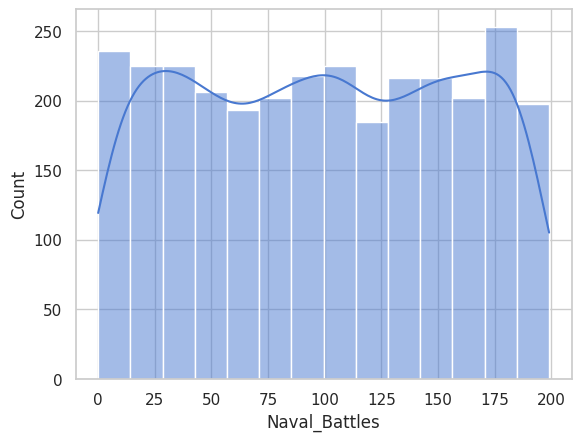

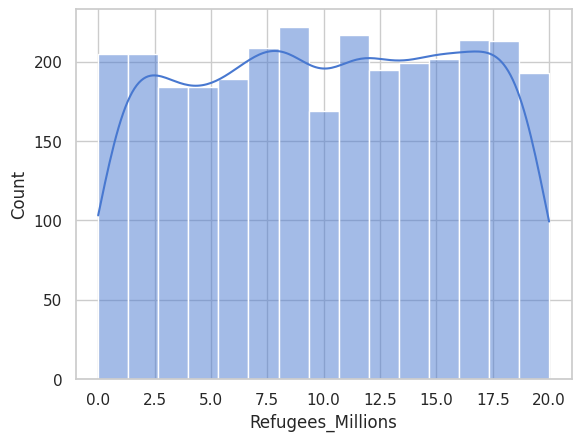

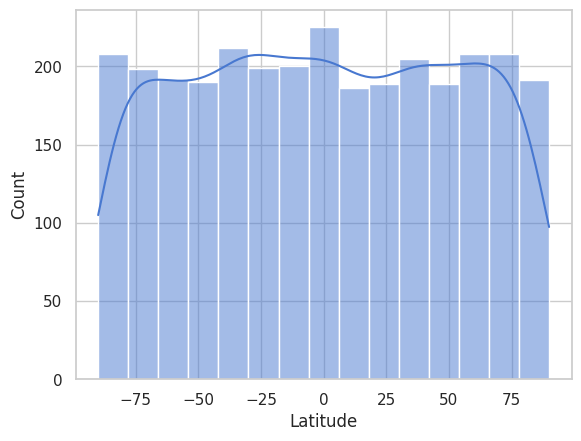

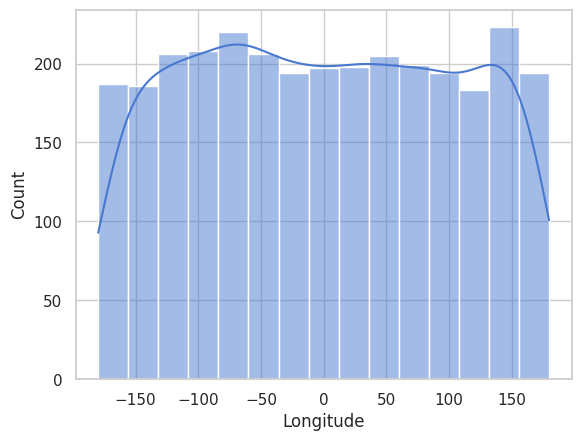

In [7]:
numeric_cols = df.select_dtypes(include=['number']).columns

# رسم التوزيع لكل عمود رقمي
for col in numeric_cols:
    sns.histplot(x=col, data=df, kde=True)
    plt.show()

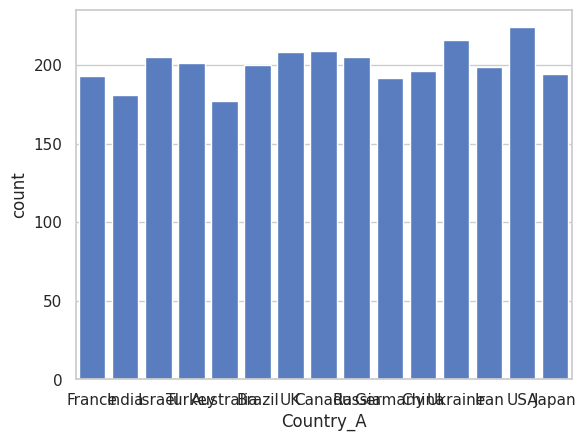

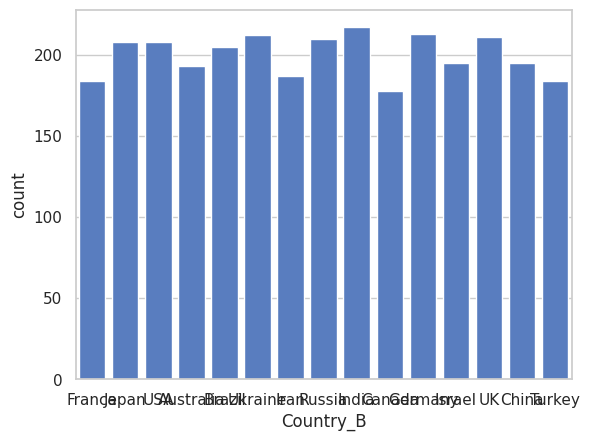

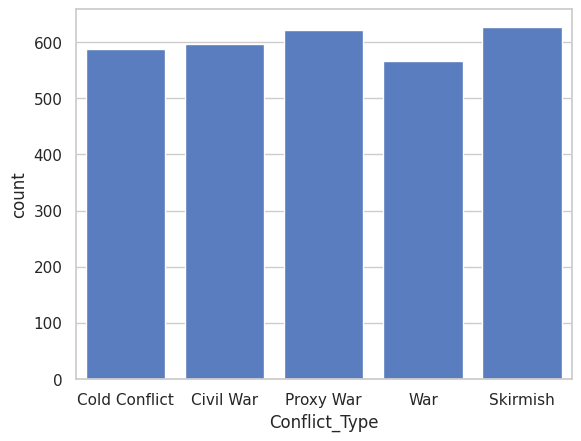

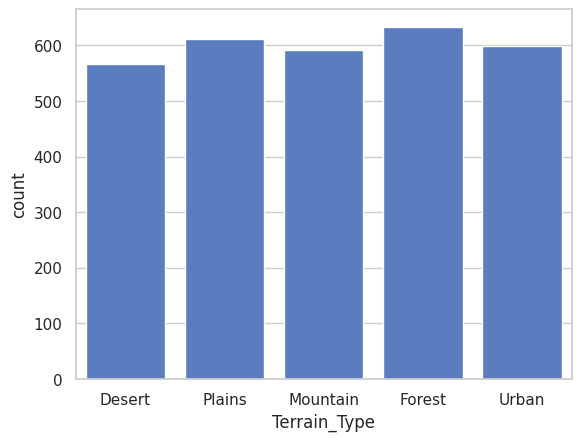

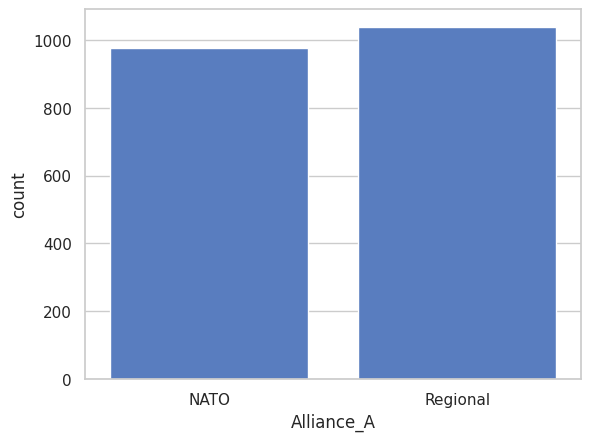

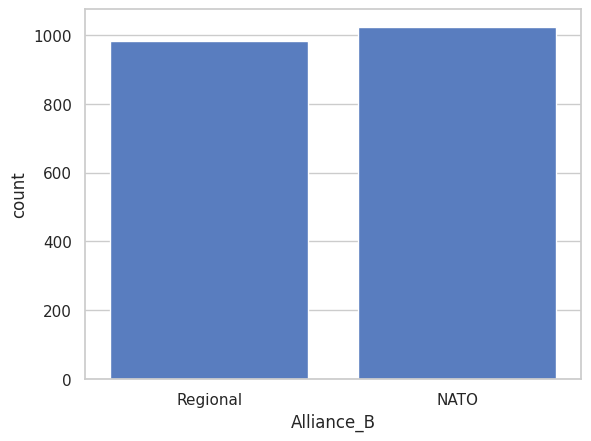

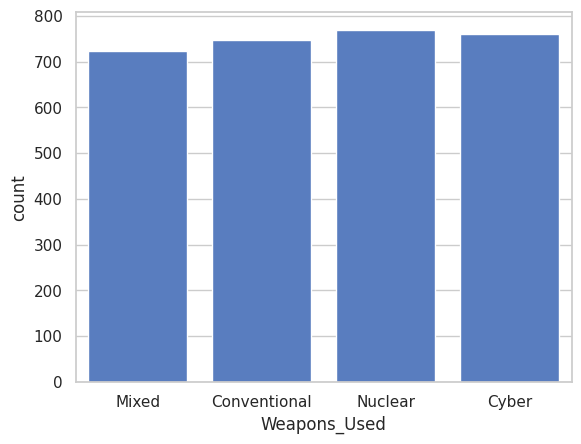

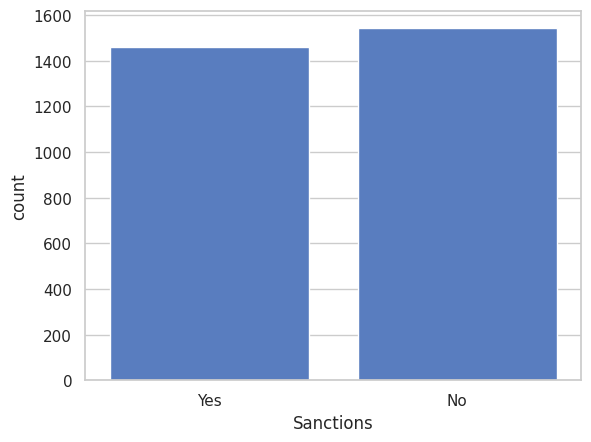

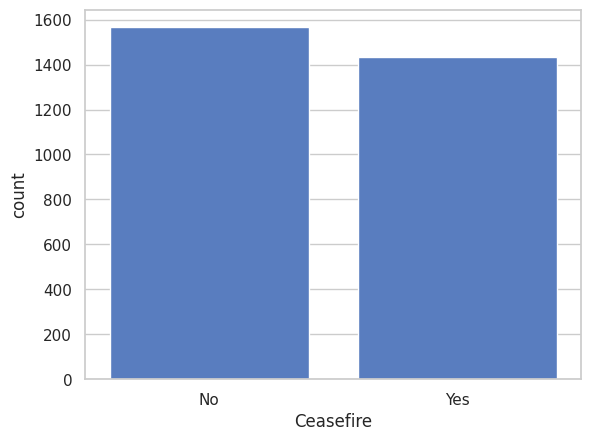

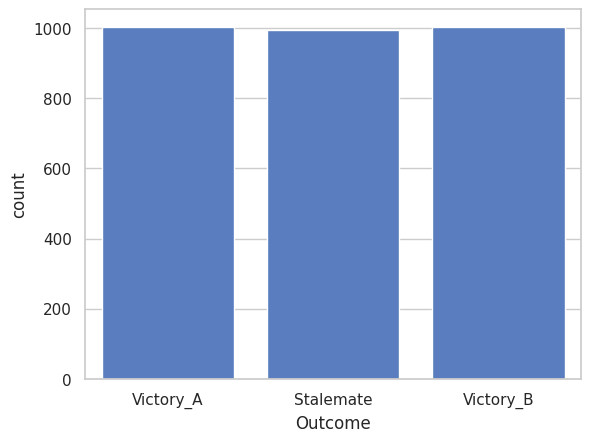

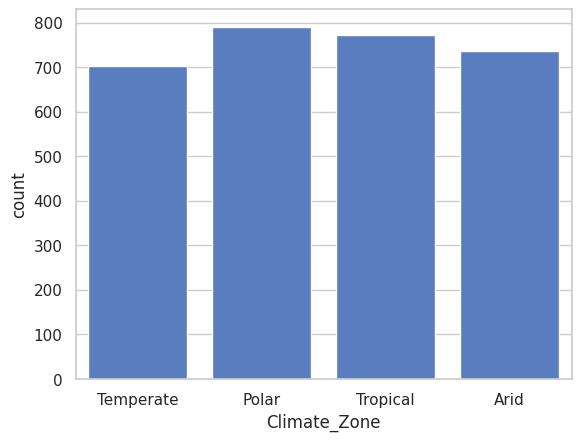

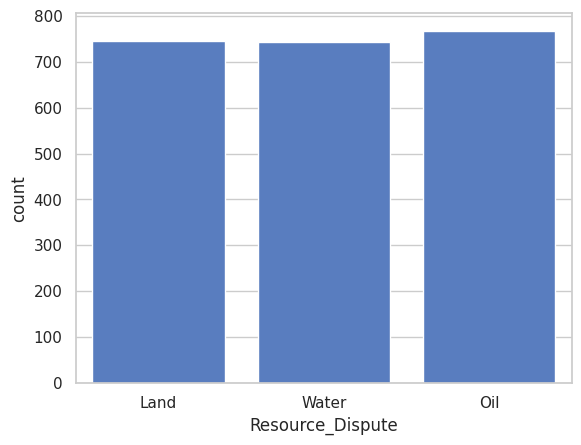

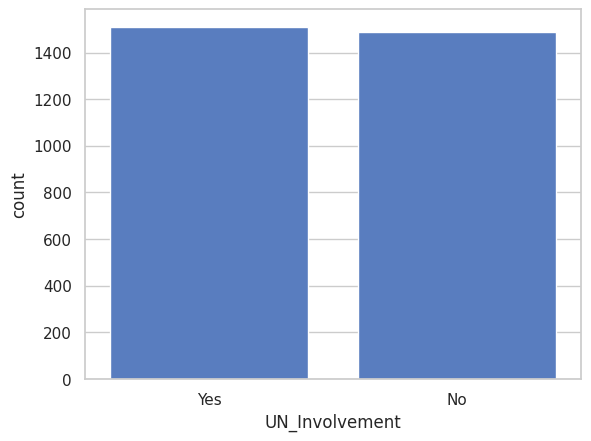

In [8]:
for col in df:
    if df[col].dtype == 'O':
        sns.countplot(x=col,data=df)
        plt.show()